# Chapter 22: Vision and Multimodal: When You Need a VLM

**If the label signal sits low in the embedding's variance ranking, what does a PCA that keeps 90% of the variance leave for the second stage?**

The chapter says PCA preserves variance under its fitted distribution, not necessarily task information, and that a percentage of lost predictive signal cannot be inferred from explained variance. Measuring a constructed case makes that concrete and shows the safer routine.

*Constructed data. Where the signal sits is a choice made by the generator; the activity measures what each rule does for each choice and does not claim real embeddings look like this.*

## The experiment

Twenty-four constructed binary tasks per setting. A 40-dimensional embedding has directions with geometrically decaying variance. Five directions starting at the control's variance rank carry the class, each shifted by the same number of its own standard deviations, so the information is identical wherever the signal sits. A noisy soft label stands in for the VLM output. A logistic regression second stage is fitted on 600 rows and scored on 4,000 new rows with: the soft label alone, the soft label plus the raw embedding, the soft label plus k principal components (k from 2 to 32, PCA fitted on the training rows only), a 90% variance rule, and the candidate chosen by 5-fold cross-validation among all of these inside the 600 rows.

In [1]:
import numpy as np
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler

from kaggle_companion.activities._common import clean

SEED = 22
REPLICATES = 24            # independent constructed datasets; every estimate is their mean
D = 40                     # embedding dimension
VARIANCE = np.exp(-0.15 * np.arange(D))     # variance of each embedding direction, largest first
KS = [2, 4, 8, 16, 24, 32]  # candidate numbers of principal components
N_TRAIN, N_NEW, WIDTH = 600, 4000, 5
SEPARATION = 0.75          # class shift per signal direction, in standard deviations of that direction


def generate(n, rng, signal_rank):
    """Embedding plus a noisy VLM soft label. Five embedding directions, starting at variance rank `signal_rank`, carry the class.

    Every signal direction is shifted by the same number of its own standard deviations, so the information in the embedding
    is identical wherever the signal sits; only its place in the variance ranking changes."""
    y = rng.integers(0, 2, n)
    sign = 2 * y - 1
    z = rng.normal(size=(n, D)) * np.sqrt(VARIANCE)
    rows = np.arange(signal_rank, signal_rank + WIDTH)
    z[:, rows] += (SEPARATION / 2) * np.sqrt(VARIANCE[rows]) * sign[:, None]
    soft = sign * 0.55 + rng.normal(size=n)            # the VLM's output as a logit-like score, informative but noisy
    return z, soft, y


def second_stage(train_features, y_train, new_features):
    """Standardize, fit logistic regression and return predicted classes for the new features."""
    scaler = StandardScaler().fit(train_features)
    model = LogisticRegression(C=1.0, max_iter=500).fit(scaler.transform(train_features), y_train)
    return model.predict(scaler.transform(new_features))


def features(kind, z_fit, soft_fit, z_apply, soft_apply):
    """Second-stage inputs for one candidate: soft label only, soft label + raw embedding, or soft label + k principal components."""
    if kind == "soft":
        return soft_fit[:, None], soft_apply[:, None]
    if kind == "raw":
        return np.column_stack([soft_fit, z_fit]), np.column_stack([soft_apply, z_apply])
    pca = PCA(kind).fit(z_fit)                          # fitted on the fitting rows only
    return np.column_stack([soft_fit, pca.transform(z_fit)]), np.column_stack([soft_apply, pca.transform(z_apply)])


def one_dataset(signal_rank, seed):
    rng = np.random.default_rng(seed)
    z, soft, y = generate(N_TRAIN, rng, signal_rank)
    z_new, soft_new, y_new = generate(N_NEW, rng, signal_rank)
    candidates = ["soft"] + KS + ["raw"]
    new_accuracy = {}
    for kind in candidates:
        a, b = features(kind, z, soft, z_new, soft_new)
        new_accuracy[kind] = (second_stage(a, y, b) == y_new).mean()
    # Choose among the candidates by 5-fold cross-validation inside the development rows; ties keep the earlier (simpler) one.
    cv = {kind: 0.0 for kind in candidates}
    for fit, val in StratifiedKFold(5, shuffle=True, random_state=0).split(z, y):
        for kind in candidates:
            a, b = features(kind, z[fit], soft[fit], z[val], soft[val])
            cv[kind] += (second_stage(a, y[fit], b) == y[val]).mean() / 5
    chosen = max(candidates, key=lambda c: (round(cv[c], 6), -candidates.index(c)))
    # The habit the chapter warns about: keep enough components for 90% of the explained variance.
    k90 = PCA(0.90).fit(z).n_components_
    a, b = features(int(k90), z, soft, z_new, soft_new)
    variance90 = (second_stage(a, y, b) == y_new).mean()
    explained = np.cumsum(PCA(D).fit(z).explained_variance_ratio_)
    return new_accuracy, chosen, k90, variance90, explained


def run(signal_rank):
    sets = [one_dataset(signal_rank, SEED * 1000 + i) for i in range(REPLICATES)]
    candidates = ["soft"] + KS + ["raw"]
    mean_new = {str(c): float(np.mean([s[0][c] for s in sets])) for c in candidates}
    chosen_accuracy = float(np.mean([s[0][s[1]] for s in sets]))
    explained = np.mean([s[4] for s in sets], axis=0)
    return clean({
        "signal_rank": signal_rank, "replicates": REPLICATES, "embedding_dimension": D, "train_rows": N_TRAIN, "new_rows": N_NEW,
        "soft_only": mean_new["soft"], "raw_embedding": mean_new["raw"],
        "pca_by_k": {str(k): mean_new[str(k)] for k in KS},
        "explained_by_k": {str(k): float(explained[k - 1]) for k in KS},
        "variance_rule": {"accuracy": float(np.mean([s[3] for s in sets])), "components": float(np.mean([s[2] for s in sets])),
                          "explained": float(explained[int(round(np.mean([s[2] for s in sets]))) - 1])},
        "cv_choice": {"accuracy": chosen_accuracy,
                      "share_soft_only": float(np.mean([s[1] == "soft" for s in sets])),
                      "share_raw": float(np.mean([s[1] == "raw" for s in sets]))},
    })


## Measure it across the control

The control is **variance rank where the label signal starts (0 is the largest-variance direction)**. Each value below runs the whole experiment from the generator up.

In [2]:
import pandas as pd
from kaggle_companion.activities.ch22 import explain

VALUES = [0, 10, 20, 30]
results = {value: run(value) for value in VALUES}
table = pd.DataFrame({str(v): explain(results[v], v)['metrics'] for v in VALUES})
print(table.to_string())

                                0     10     20     30
Soft label alone            0.707  0.707  0.707  0.707
Raw embedding               0.823  0.823  0.823  0.824
90% variance rule           0.835  0.834  0.695  0.696
Cross-validated choice      0.835  0.831  0.826  0.823
Components in the 90% rule     15     15     16     15


## Look at it

The figure shows the default setting, variance rank where the label signal starts (0 is the largest-variance direction) = 20.

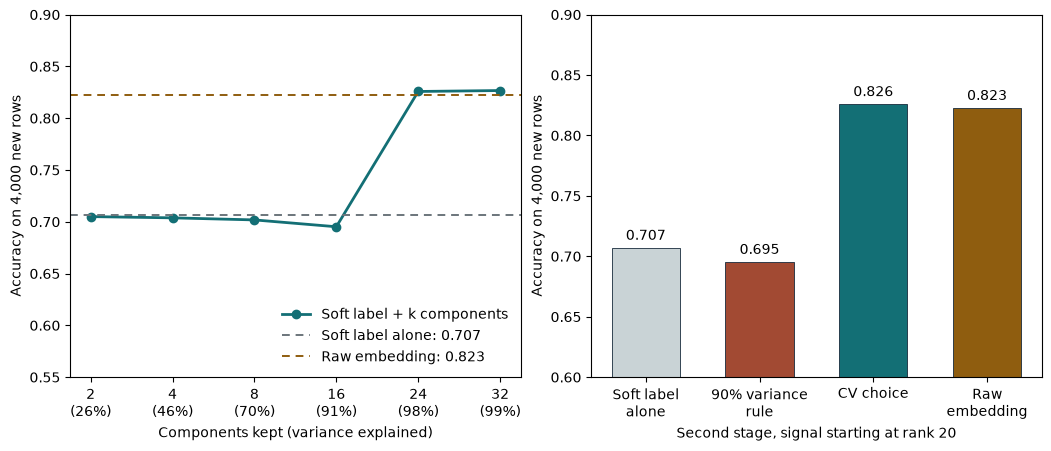

In [3]:
import matplotlib.pyplot as plt
from kaggle_companion.activities.ch22 import draw, NCOLS, HEIGHT

DEFAULT = 20
fig, axes = plt.subplots(1, NCOLS, figsize=(6.6 if NCOLS == 1 else 10.4, HEIGHT), layout='constrained')
draw(axes, results[DEFAULT], DEFAULT)
plt.show()

## What the result says

With the signal starting at variance rank 20, the 90% rule keeps about 16 components (91% of the variance) and scores 0.695, against 0.707 for the soft label alone and 0.823 for the raw embedding: 0.695 - 0.707 = -0.012, so the reduced embedding has lost the signal. Choosing by cross-validation scores 0.826, and 0.826 - 0.695 = 0.131 is its margin over the rule.

- Soft label alone: 0.707. Raw embedding plus soft label: 0.823.
- 90% variance rule: 0.695 with about 16 components.
- Variance rule against soft label alone: 0.695 - 0.707 = -0.012.
- Cross-validated choice: 0.826; it picked the soft label alone in 0.00 of datasets.

## Apply this to your competition

- Compare the soft outputs alone, the raw embedding and a few PCA sizes inside the development folds before adding any reduction.
- Fit the projection on training rows only, inside each fold, and assess the frozen choice on rows it never saw.
- Never read explained variance as signal kept: a projection that keeps 90% of the variance can keep none of the label information.
- Record the comparison, including the failed reduction, as the chapter does for the Autopilot pipeline.

Book location: Chapter 22, When VLMs Beat Traditional CV Pipelines.

[Technical corrections](https://github.com/KarpelesPublishing/winning-kaggle-companion/blob/main/docs/errata.md)